In [81]:
import pandas as pd 
import matplotlib.pyplot as plt


In [82]:
data=pd.read_csv("../data/clean/cleandata.csv",index_col="time", parse_dates=True)


In [83]:
data["Significant wave height"].describe()

count    40214.000000
mean         1.833272
std          0.981496
min          0.500000
25%          1.160000
50%          1.580000
75%          2.210000
max         12.060000
Name: Significant wave height, dtype: float64

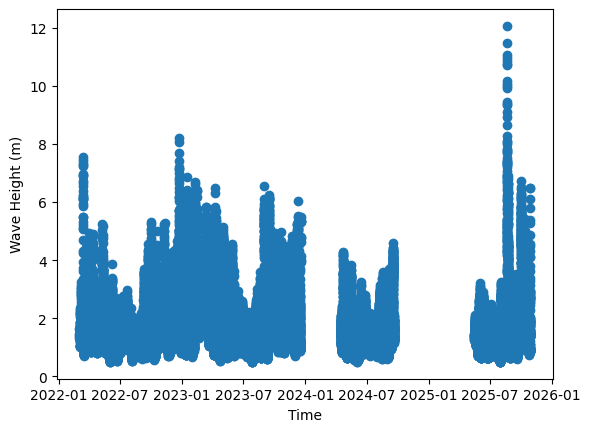

In [84]:
plt.scatter(data.index, data['Significant wave height'])
plt.xlabel("Time")
plt.ylabel("Wave Height (m)")
plt.show()

# Decomposition

In [85]:
from statsmodels.tsa.seasonal import seasonal_decompose

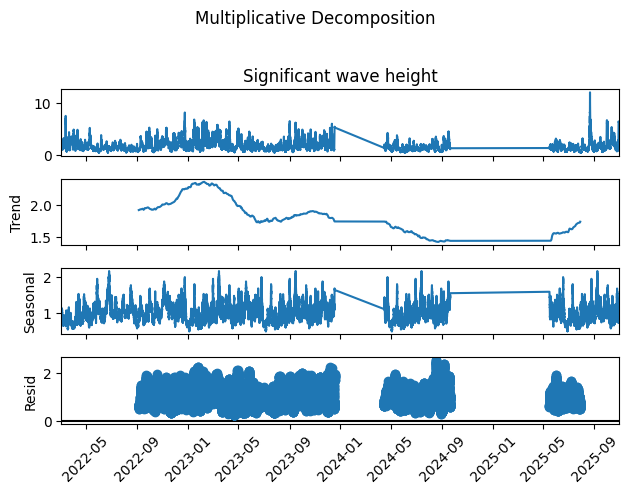

In [86]:
decomposition_multi = seasonal_decompose(data['Significant wave height'],
     model='multiplicative', period=24*365)
fig = decomposition_multi.plot()
fig.suptitle("Multiplicative Decomposition", y=1.02)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

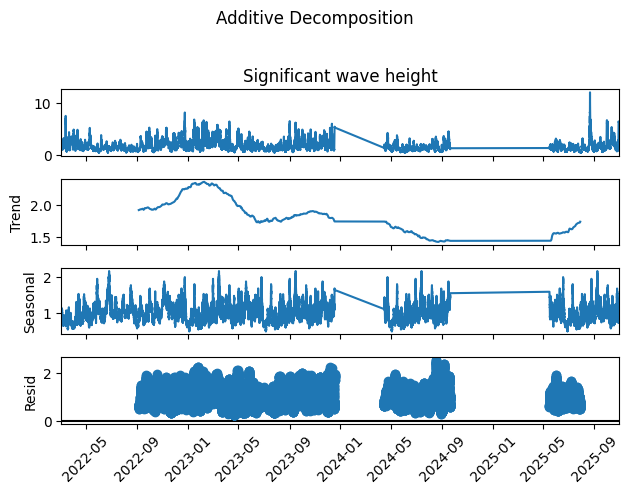

In [87]:
decomposition_add = seasonal_decompose(data['Significant wave height'],
     model='additive',period=24*365)
fig = decomposition_multi.plot()
fig.suptitle("Additive Decomposition", y=1.02)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Note on the 2024–2025 gap: the buoy has no recorded data from ~Sept 2024–mid 2025 (raw files stop early). Decomposition results for 2022–2024 (dense real data) are considered reliable; anything spanning or immediately adjacent to the gap should be read with that caveat.

# Autocorrelation

In [88]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf


(0.0, 1.0)

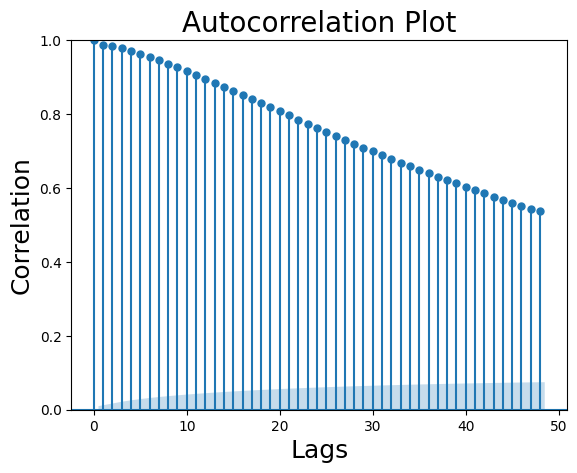

In [89]:
plot_acf(data['Significant wave height'].dropna(), lags=48)
plt.title('Autocorrelation Plot', fontsize=20)
plt.xlabel('Lags', fontsize=18)
plt.ylabel('Correlation', fontsize=18)
plt.ylim(0,1)

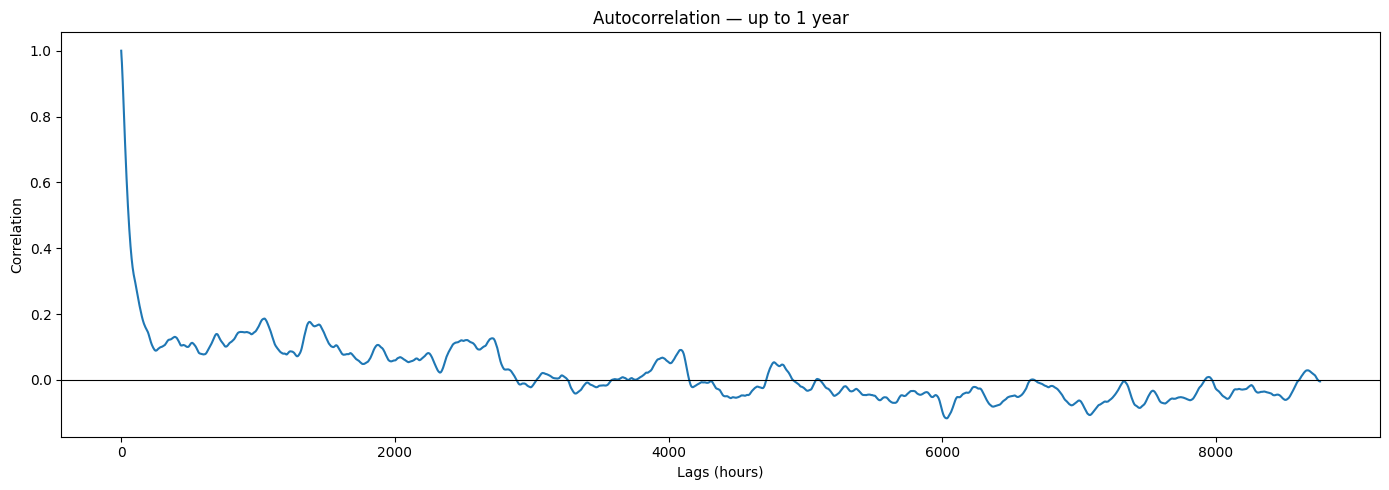

In [90]:

acf_vals = acf(data['Significant wave height'].dropna(), nlags=24*365, fft=True)

plt.figure(figsize=(14,5))
plt.plot(acf_vals)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Lags (hours)')
plt.ylabel('Correlation')
plt.title('Autocorrelation — up to 1 year')
plt.tight_layout()
plt.show()

In [91]:
wvht = data["Significant wave height"].copy()

In [92]:
print(wvht.describe())
print(wvht.min())
print(wvht.max())
print(wvht.isna().sum())

count    40214.000000
mean         1.833272
std          0.981496
min          0.500000
25%          1.160000
50%          1.580000
75%          2.210000
max         12.060000
Name: Significant wave height, dtype: float64
0.5
12.06
0


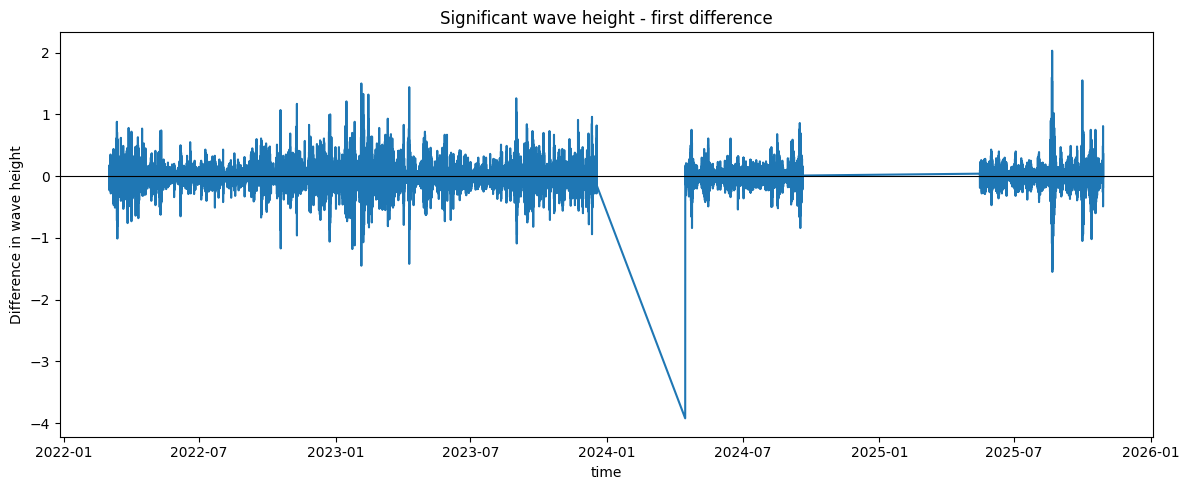

In [93]:
wvht_diff = wvht.diff()

plt.figure(figsize=(12, 5))
plt.plot(wvht_diff)

plt.axhline(0, color="black", linewidth=0.8)

plt.xlabel("time")
plt.ylabel("Difference in wave height")
plt.title("Significant wave height - first difference")

plt.tight_layout()
plt.show()

In [94]:
wvht_diff.abs().sort_values(ascending=False).head(20)

time
2024-04-14 22:10:00    3.92
2025-08-21 05:40:00    2.03
2025-08-20 21:40:00    1.60
2025-09-30 20:10:00    1.55
2025-08-21 12:10:00    1.55
2025-08-21 04:10:00    1.54
2025-08-21 04:40:00    1.51
2025-08-21 13:10:00    1.51
2023-02-04 12:40:00    1.50
2023-02-04 13:10:00    1.45
2023-04-09 21:40:00    1.44
2023-04-09 22:10:00    1.42
2025-08-21 06:10:00    1.39
2025-08-21 08:10:00    1.34
2023-02-07 02:40:00    1.33
2023-02-13 23:10:00    1.32
2023-08-31 19:10:00    1.26
2023-01-15 11:40:00    1.21
2023-01-23 10:10:00    1.18
2022-11-09 21:40:00    1.17
Name: Significant wave height, dtype: float64

In [95]:
import numpy as np

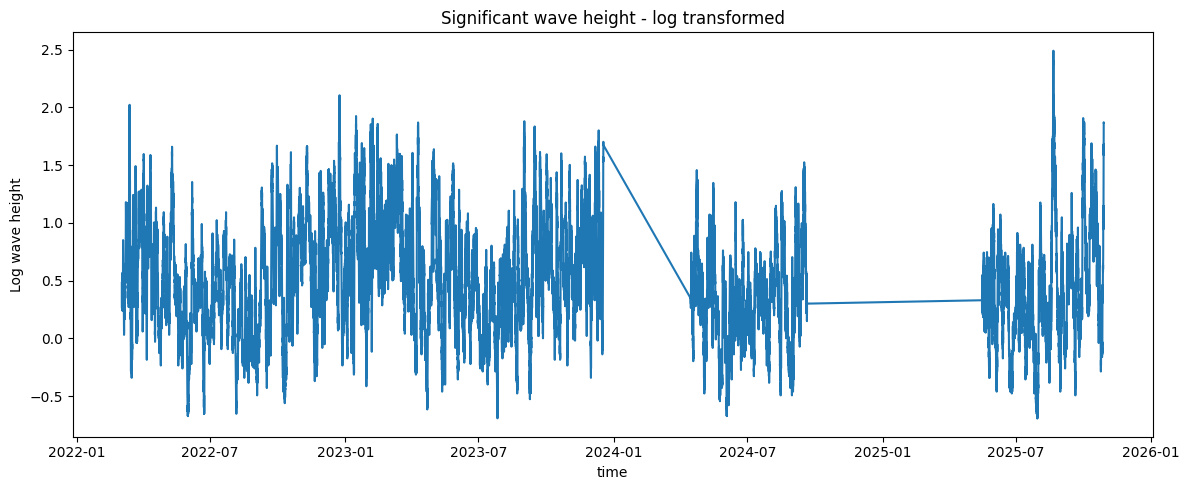

In [96]:
wvht_log = np.log(wvht)

plt.figure(figsize=(12, 5))
plt.plot(wvht_log)

plt.xlabel("time")
plt.ylabel("Log wave height")
plt.title("Significant wave height - log transformed")

plt.tight_layout()
plt.show()


In [97]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
result = adfuller(data["Significant wave height"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -15.27757993765777
p-value: 4.62512865857161e-28


In [99]:
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

Critical Values:
1%: -3.4305127281212315
5%: -2.861611922100618
10%: -2.5668082818228446


Since the ADF value < the critical 1% value this is staionary